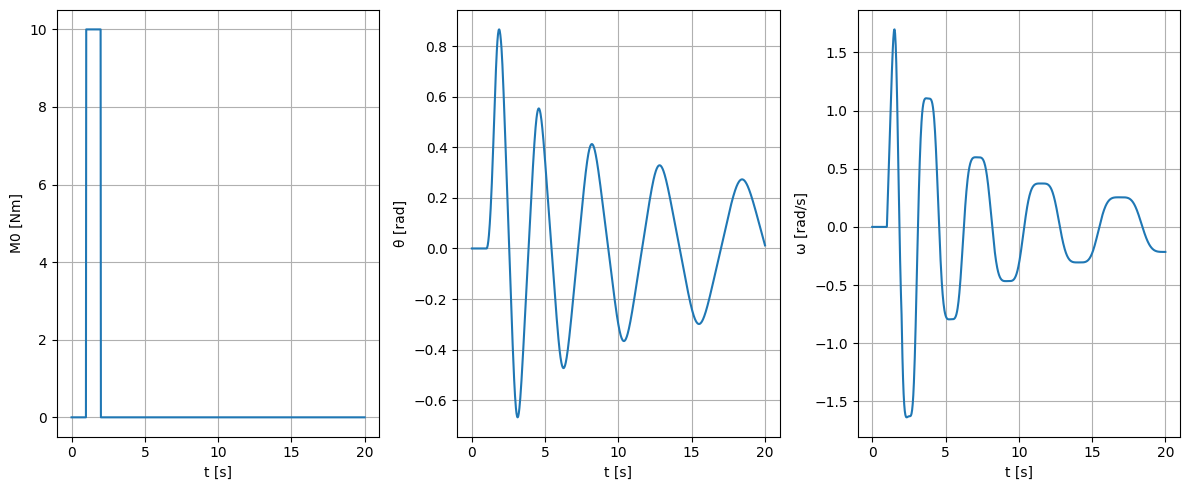

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def CME_jou_escoces():

    # Dades del problema
    t_start = 0
    t_end   = 20
    t_eps1  = 1
    t_eps2  = 2

    R = 100e-3       # [m]
    k = 10e3         # [N/m]
    m = 5            # [kg]
    J = 0.5 * 500 * R**2
    c = 1000         # [Ns/m]

    M_o = 10       # [Nm]

    initial_position = 0
    initial_speed    = 0

    # Funció moment aplicat
    def Q_x(t):
        if t < t_eps1 or t > t_eps2:
            return 0
        else:
            return M_o

    # RHS (equacions diferencials)
    def rhs(t, x):

        theta = x[0]
        omega = x[1]

        m_eq = m * R**2 * np.sin(theta)**2 + J

        xdot_1 = omega

        xdot_2 = -(m * R**2 * np.sin(theta) * np.cos(theta) / m_eq) * omega**2 \
                 -(c * R**2 * np.sin(theta)**2 / m_eq) * omega \
                 -(k * R**2 * np.sin(theta) * (1 - np.cos(theta)) / m_eq) \
                 + Q_x(t) / m_eq

        return [xdot_1, xdot_2]

    # Integració numèrica (equivalent a ode23t de MATLAB)
    sol = solve_ivp(
        rhs,
        [t_start, t_end],
        [initial_position, initial_speed],
        method='RK23',
        t_eval=np.linspace(t_start, t_end, 1000)
    )

    t = sol.t
    x = sol.y

    # Moment aplicat per la gràfica
    M = [Q_x(time) for time in t]

    # Gràfiques
    plt.figure(figsize=(12,5))

    plt.subplot(1,3,1)
    plt.plot(t, M)
    plt.xlabel('t [s]')
    plt.ylabel('M0 [Nm]')
    plt.grid()

    plt.subplot(1,3,2)
    plt.plot(t, x[0])
    plt.xlabel('t [s]')
    plt.ylabel('θ [rad]')
    plt.grid()

    plt.subplot(1,3,3)
    plt.plot(t, x[1])
    plt.xlabel('t [s]')
    plt.ylabel('ω [rad/s]')
    plt.grid()

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    CME_jou_escoces()